In [321]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
%matplotlib inline

In [322]:
df = pd.read_csv('df_cleaned.csv')
df.head()

,Unnamed: 0,date,category_name,item_id,sold_quantity,price,revenue,store_id,month,day_of_week,...,visibility,pressure,cloudcover,dewpoint,windgust,uv_index,date_zipcode,special_day,school_holiday,std_holiday
0,0,2025-04-01,Angebot Brötchen,547,15.0,0.0,0.0,0,4,1,...,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
1,1,2025-04-01,Angebot Feinbäckerei,203,28.0,0.0,0.0,0,4,1,...,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
2,2,2025-04-01,Angebot Heißgetränke,346,25.0,0.0,0.0,0,4,1,...,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
3,3,2025-04-01,Angebot Heißgetränke,445,5.0,1.4,7.0,0,4,1,...,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0
4,4,2025-04-01,Angebot Snack,330,5.0,0.0,0.0,0,4,1,...,10.0,1025.75,5.833333,0.75,25.958333,2.166667,520622025-04-01,1,0,0


In [323]:
print('Before mapping: ', df.weather_description.value_counts())
weather_map = {'Clear': 'clear',
               'Patchy rain possible': 'rainy',
               'Partly cloudy': 'cloudy',
               'Sunny': 'clear',
               'Light rain shower': 'rainy',
               'Overcast': 'cloudy',
               'Light drizzle': 'cloudy',
               'Mist': 'fog',
               'Fog': 'fog',
               'Cloudy': 'Cloudy'}
df.weather_description = df.weather_description.map(weather_map)
print('After mapping: ', df.weather_description.value_counts())

Before mapping:  weather_description
Clear                   289262
Patchy rain possible    147805
Partly cloudy           125317
Sunny                   108080
Light rain shower        41167
Overcast                 10942
Light drizzle             8001
Mist                       545
Fog                         63
Cloudy                      46
Name: count, dtype: int64
After mapping:  weather_description
clear     397342
rainy     188972
cloudy    144260
fog          608
Cloudy        46
Name: count, dtype: int64


In [324]:
print('Revenue does not provide more informaiton, it is correlated to price and sold_quantity, thus remove this column')
df = df.drop('revenue', axis = 1)
# remove the index column and the column which was used to join the dataframes
# date and weeks are removed from the analysis
df = df.drop(['Unnamed: 0', 'date_zipcode'], axis=1)

Revenue does not provide more informaiton, it is correlated to price and sold_quantity, thus remove this column


In [325]:
df['std_holiday_tomorrow'] = df['std_holiday'].shift(-1)
df['quantity_lag_7'] = df['sold_quantity'].shift(7)
df = df.dropna()
df.head()

,date,category_name,item_id,sold_quantity,price,store_id,month,day_of_week,week,zipcode,...,pressure,cloudcover,dewpoint,windgust,uv_index,special_day,school_holiday,std_holiday,std_holiday_tomorrow,quantity_lag_7
7,2025-04-01,Brot,38,4.0,4.15,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,15.0
8,2025-04-01,Brot,42,3.0,1.70,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,28.0
9,2025-04-01,Brot,44,10.0,3.78,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,25.0
10,2025-04-01,Brot,46,0.0,3.80,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,5.0
11,2025-04-01,Brot,51,3.0,3.60,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,5.0


In [326]:
df.columns
df.head(14)

,date,category_name,item_id,sold_quantity,price,store_id,month,day_of_week,week,zipcode,...,pressure,cloudcover,dewpoint,windgust,uv_index,special_day,school_holiday,std_holiday,std_holiday_tomorrow,quantity_lag_7
7,2025-04-01,Brot,38,4.00,4.15,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,15.0
8,2025-04-01,Brot,42,3.00,1.70,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,28.0
9,2025-04-01,Brot,44,10.00,3.78,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,25.0
10,2025-04-01,Brot,46,0.00,3.80,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,5.0
11,2025-04-01,Brot,51,3.00,3.60,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,5.0
12,2025-04-01,Brot,59,16.50,3.52,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,1.0
13,2025-04-01,Brot,80,13.00,3.80,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,1.0
14,2025-04-01,Brot,99,0.50,4.80,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,4.0
15,2025-04-01,Brot,116,2.00,3.50,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,3.0
16,2025-04-01,Brot,120,1.00,2.65,0,4,1,14,52062,...,1025.75,5.833333,0.75,25.958333,2.166667,1,0,0,0.0,10.0


<Axes: >

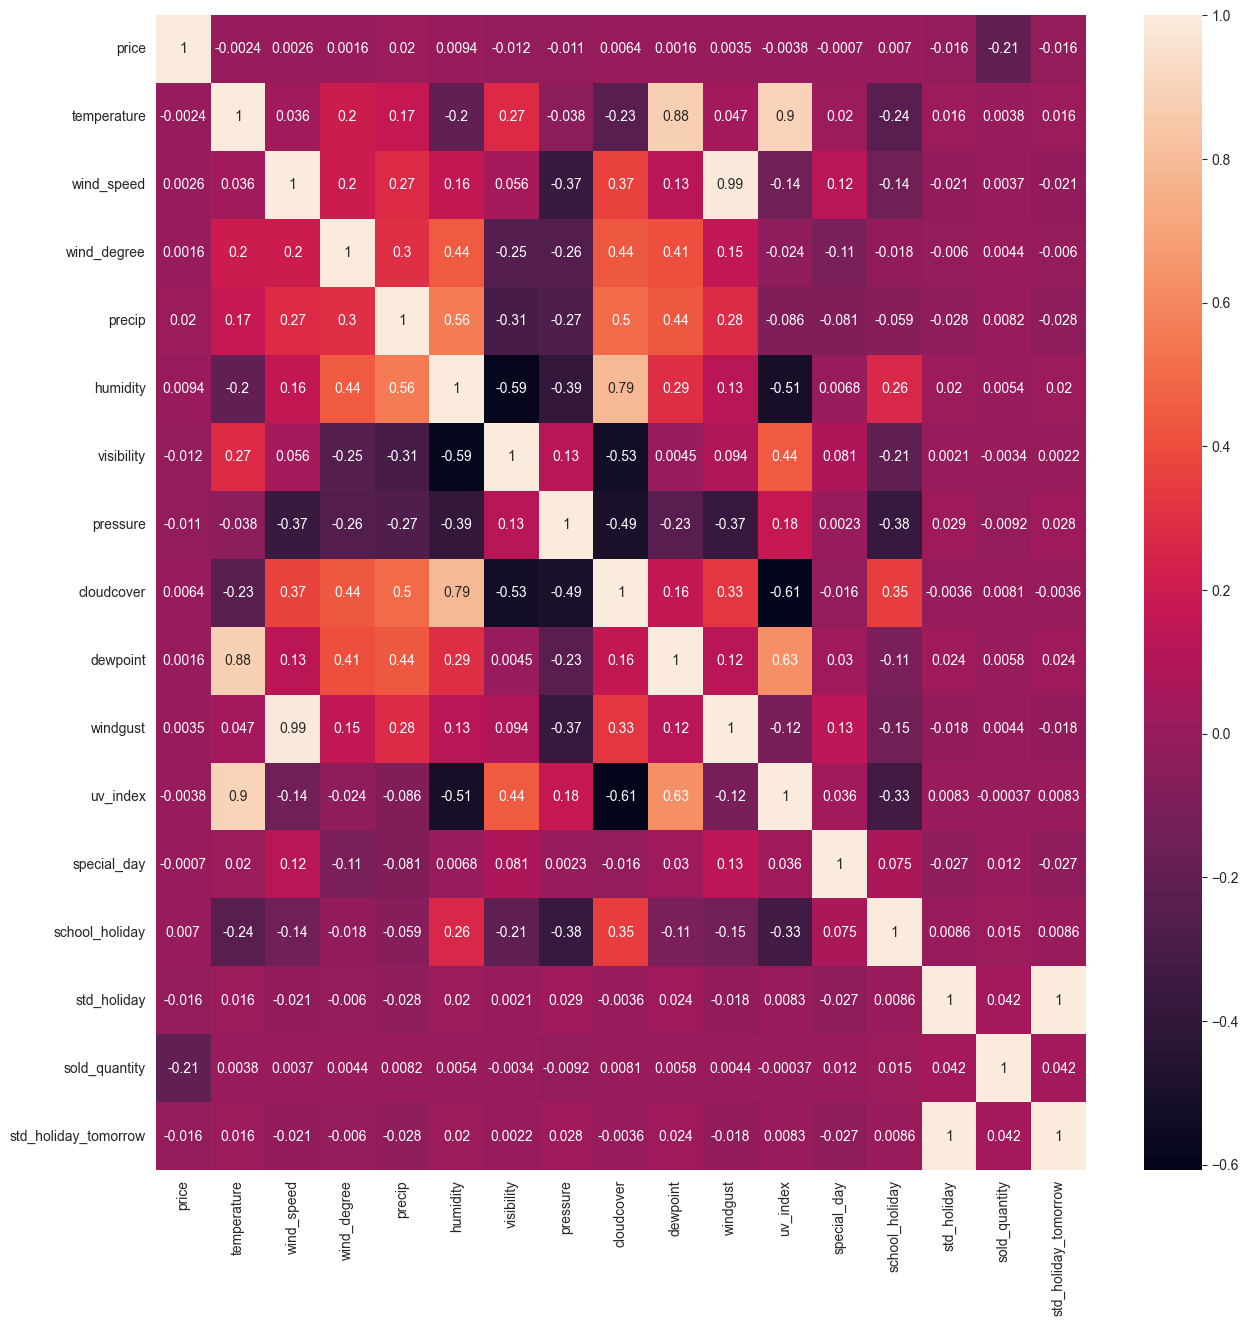

In [327]:

num_features_col = ['price', 'temperature', 'wind_speed', 'wind_degree','precip', 'humidity', 'visibility', 'pressure', 'cloudcover', 'dewpoint', 'windgust', 'uv_index', 'special_day', 'school_holiday', 'std_holiday', 'sold_quantity', 'std_holiday_tomorrow']
num_features = pd.DataFrame(df[num_features_col])
plt.figure(figsize=(15, 15))
sns.heatmap(num_features.corr(), annot = True)


In [328]:
# wind_speed and windgust is strongly correlated -> keep wind_speed
# temperature, uv_index, dewpoint are strongly correlated -> keep temperature
df = df.drop(['windgust', 'uv_index', 'dewpoint'], axis = 1)
num_features = num_features.drop(['windgust', 'uv_index', 'dewpoint'], axis = 1)
#sns.pairplot(num_features)

In [329]:
num_features.corr(method='spearman', numeric_only=True)['sold_quantity']

price                  -0.366613
temperature             0.006639
wind_speed              0.001569
wind_degree             0.006104
precip                  0.002471
humidity                0.005420
visibility             -0.004760
pressure               -0.002795
cloudcover              0.006617
special_day             0.016975
school_holiday          0.006042
std_holiday             0.027810
sold_quantity           1.000000
std_holiday_tomorrow    0.027809
Name: sold_quantity, dtype: float64

Text(0.5, 1.0, 'daily quantity by day of week')

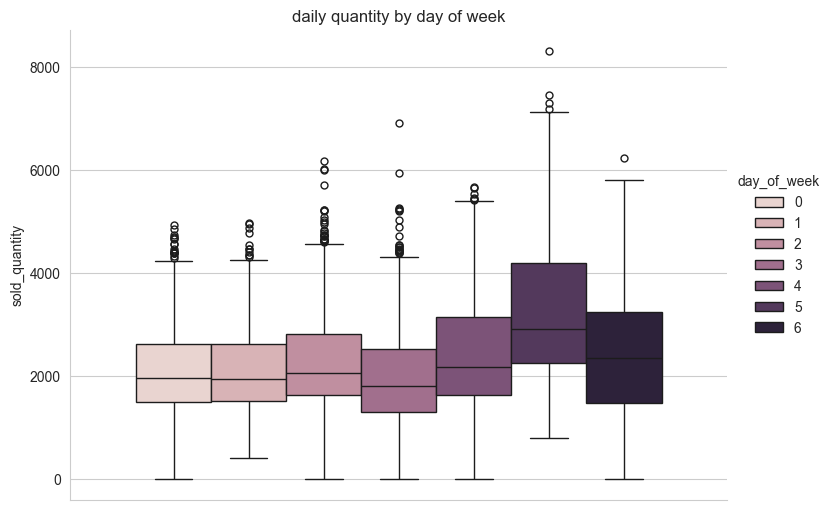

In [330]:
daily_quantity = df[['date', 'day_of_week', 'sold_quantity', 'store_id']].groupby(['date','day_of_week', 'store_id']).sum()
daily_quantity = daily_quantity.reset_index()
sns.set_style("whitegrid")
sns.catplot(y='sold_quantity', data = daily_quantity, hue = 'day_of_week', kind = 'box', aspect = 1.5)
plt.title('daily quantity by day of week')

In [331]:
X = df.drop(['week', 'month', 'sold_quantity', 'category_name'], axis = 1)
y = df['sold_quantity']

In [332]:
from sklearn.model_selection import train_test_split
train_split_method = 'time'
if train_split_method == 'random':
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 12)
elif train_split_method == 'time':
    test_size = len(X) * 0.25
    X_train = X.iloc[range(0,int(test_size)),]
    y_train = y[0:int(test_size)]
    X_test = X.iloc[range(int(test_size), len(X)),]
    y_test = y[int(test_size):len(X)]


### Encode item id

     item_id  sold_quantity
571      675     680.208333
266      311     624.920971
114      133     567.448287
108      126     410.895954
415      491     388.819462
..       ...            ...
726      849       0.172837
523      618       0.111916
562      661       0.017241
170      197       0.003375
490      578       0.000237

[815 rows x 2 columns]


,date,category_name,item_id,sold_quantity,price,store_id,month,day_of_week,week,zipcode,...,precip,humidity,visibility,pressure,cloudcover,special_day,school_holiday,std_holiday,std_holiday_tomorrow,quantity_lag_7
791,2025-04-01,Brötchen,675,599.0,0.55,3,4,1,14,52062,...,0.000000,64.458333,10.000000,1025.750000,5.833333,1,0,0,0.0,9.0
10284,2025-04-02,Brötchen,675,610.0,0.55,3,4,2,14,52062,...,0.000000,65.541667,10.000000,1022.166667,9.875000,1,0,0,0.0,31.0
19545,2025-04-03,Brötchen,675,756.0,0.55,3,4,3,14,52062,...,0.000000,62.041667,10.000000,1022.833333,31.916667,0,0,0,0.0,12.0
28816,2025-04-04,Brötchen,675,877.0,0.55,3,4,4,14,52062,...,0.000000,60.083333,10.000000,1020.791667,0.083333,0,0,0,0.0,8.0
38504,2025-04-05,Brötchen,675,905.0,0.55,3,4,5,14,52062,...,0.000000,59.875000,10.000000,1017.666667,13.583333,0,0,0,0.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
683028,2025-06-25,Brötchen,675,446.0,0.55,3,6,2,26,52062,...,0.000000,62.250000,10.000000,1012.958333,17.166667,0,0,0,0.0,30.0
692048,2025-06-26,Brötchen,675,429.0,0.55,3,6,3,26,52062,...,0.200000,76.125000,9.666667,1013.791667,66.208333,0,0,0,0.0,27.0
700995,2025-06-27,Brötchen,675,796.0,0.55,3,6,4,26,52062,...,0.004167,59.000000,10.000000,1022.375000,37.625000,0,0,0,0.0,45.0
710323,2025-06-28,Brötchen,675,922.0,0.55,3,6,5,26,52062,...,0.000000,65.375000,10.000000,1024.000000,15.500000,0,0,0,0.0,19.0


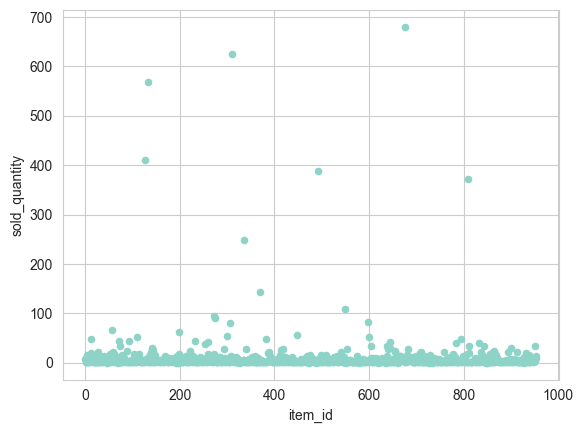

In [333]:

df_grouped = df[['item_id', 'sold_quantity']].groupby('item_id').mean().reset_index()

df_grouped.plot.scatter(x='item_id', y='sold_quantity')
print(df_grouped.sort_values('sold_quantity', ascending = False))
df[df.item_id.isin([675])]

In [334]:
import category_encoders as ce
target_encoder = ce.TargetEncoder()
item_id_train_encoded = target_encoder.fit_transform(X_train['item_id'].astype('str'), y_train)
X_train = pd.concat([X_train.drop('item_id', axis = 1), item_id_train_encoded], axis = 1)
item_id_test_encoded = target_encoder.transform(X_test['item_id'].astype('str'))
X_test = pd.concat([X_test.drop('item_id', axis = 1), item_id_test_encoded], axis = 1)
display(X_train.head())
display(X_test.head())
print(X_train.isna().any())

,date,price,store_id,day_of_week,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,...,humidity,visibility,pressure,cloudcover,special_day,school_holiday,std_holiday,std_holiday_tomorrow,quantity_lag_7,item_id
7,2025-04-01,4.15,0,1,52062,7.541667,16.5,78.625,E,clear,...,64.458333,10.0,1025.75,5.833333,1,0,0,0.0,15.0,5.467267
8,2025-04-01,1.70,0,1,52062,7.541667,16.5,78.625,E,clear,...,64.458333,10.0,1025.75,5.833333,1,0,0,0.0,28.0,9.776515
9,2025-04-01,3.78,0,1,52062,7.541667,16.5,78.625,E,clear,...,64.458333,10.0,1025.75,5.833333,1,0,0,0.0,25.0,11.909864
10,2025-04-01,3.80,0,1,52062,7.541667,16.5,78.625,E,clear,...,64.458333,10.0,1025.75,5.833333,1,0,0,0.0,5.0,1.259212
11,2025-04-01,3.60,0,1,52062,7.541667,16.5,78.625,E,clear,...,64.458333,10.0,1025.75,5.833333,1,0,0,0.0,5.0,5.242891


,date,price,store_id,day_of_week,zipcode,temperature,wind_speed,wind_degree,wind_dir,weather_description,...,humidity,visibility,pressure,cloudcover,special_day,school_holiday,std_holiday,std_holiday_tomorrow,quantity_lag_7,item_id
182812,2025-04-24,0.89,6,3,52066,8.666667,6.625,271.625,WSW,cloudy,...,93.416667,4.0,1016.833333,98.25,0,1,0,0.0,0.0,85.281250
182813,2025-04-24,1.00,6,3,52066,8.666667,6.625,271.625,WSW,cloudy,...,93.416667,4.0,1016.833333,98.25,0,1,0,0.0,9.0,53.745875
182814,2025-04-24,0.90,6,3,52066,8.666667,6.625,271.625,WSW,cloudy,...,93.416667,4.0,1016.833333,98.25,0,1,0,0.0,218.0,0.466179
182815,2025-04-24,0.82,6,3,52066,8.666667,6.625,271.625,WSW,cloudy,...,93.416667,4.0,1016.833333,98.25,0,1,0,0.0,15.0,38.557481
182816,2025-04-24,0.95,6,3,52066,8.666667,6.625,271.625,WSW,cloudy,...,93.416667,4.0,1016.833333,98.25,0,1,0,0.0,7.0,44.414122


date                    False
price                   False
store_id                False
day_of_week             False
zipcode                 False
temperature             False
wind_speed              False
wind_degree             False
wind_dir                False
weather_description     False
precip                  False
humidity                False
visibility              False
pressure                False
cloudcover              False
special_day             False
school_holiday          False
std_holiday             False
std_holiday_tomorrow    False
quantity_lag_7          False
item_id                 False
dtype: bool


### Encode weather_description and day_of_week with one hot encoder

In [335]:
cat_features_col = ['category_name', 'item_id', 'store_id', 'day_of_week', 'zipcode','wind_dir', 'weather_description']
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype='int')
encoder.fit(X_train[['weather_description','day_of_week']])
def get_onehotencoding(df, feature_list, encoder):
    df = df.reset_index()
    df = df.drop('index', axis=1)
    temp_df = pd.DataFrame(data = encoder.transform(df[feature_list]), columns = encoder.get_feature_names_out())
    df = df.drop(feature_list,axis = 1)
    df = pd.concat([df, temp_df], axis = 1)
    return df

#encode weather description and day of week with one hot encoding method
X_train = get_onehotencoding(X_train, ['weather_description','day_of_week'], encoder)
X_test = get_onehotencoding(X_test, ['weather_description','day_of_week'], encoder)


### Encode wind_dir

Text(0.5, 1.0, 'daily quantity by wind direction')

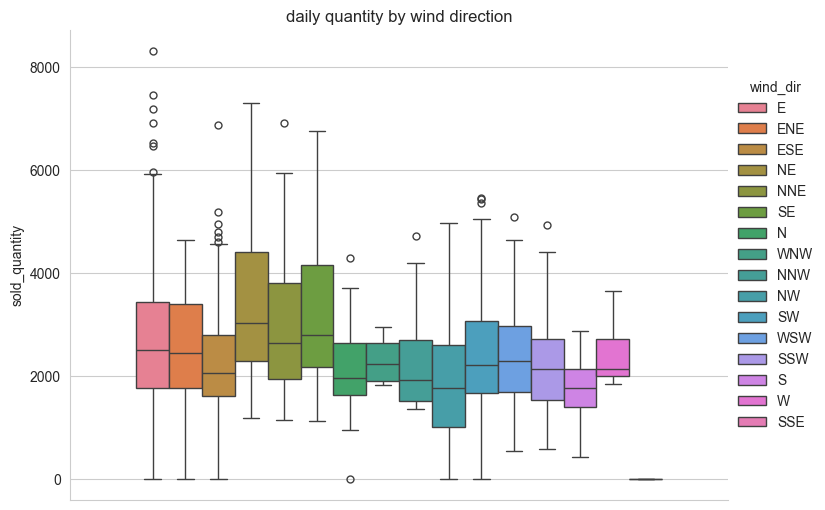

In [336]:
df_train = pd.concat([X_train, y_train.reset_index().drop('index', axis = 1)], axis = 1)
daily_quantity = df_train[['date', 'wind_dir', 'sold_quantity', 'store_id']].groupby(['date','wind_dir', 'store_id']).sum()
daily_quantity = daily_quantity.reset_index()
sns.catplot(y= 'sold_quantity', data = daily_quantity, hue = 'wind_dir', kind = 'box', aspect = 1.5)
plt.title('daily quantity by wind direction')

In [337]:
daily_store_quantity_mean = daily_quantity['sold_quantity'].mean()
wind_daily_store_mean = daily_quantity[['wind_dir', 'sold_quantity']].groupby(['wind_dir']).mean()
X_train['wind_dir'] = np.where(X_train.wind_dir.isin(wind_daily_store_mean[wind_daily_store_mean.sold_quantity > daily_store_quantity_mean].index.to_list()), 1, 0)
X_train.head()

,date,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,2025-04-01,4.15,0,52062,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
1,2025-04-01,1.70,0,52062,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
2,2025-04-01,3.78,0,52062,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
3,2025-04-01,3.80,0,52062,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
4,2025-04-01,3.60,0,52062,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0


In [338]:
X_test['wind_dir'] = np.where(X_test.wind_dir.isin(wind_daily_store_mean[wind_daily_store_mean.sold_quantity > daily_store_quantity_mean].index.to_list()), 1, 0)
X_test.head()

,date,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,2025-04-24,0.89,6,52066,8.666667,6.625,271.625,0,0.216667,93.416667,...,0,1,0,0,0,0,1,0,0,0
1,2025-04-24,1.00,6,52066,8.666667,6.625,271.625,0,0.216667,93.416667,...,0,1,0,0,0,0,1,0,0,0
2,2025-04-24,0.90,6,52066,8.666667,6.625,271.625,0,0.216667,93.416667,...,0,1,0,0,0,0,1,0,0,0
3,2025-04-24,0.82,6,52066,8.666667,6.625,271.625,0,0.216667,93.416667,...,0,1,0,0,0,0,1,0,0,0
4,2025-04-24,0.95,6,52066,8.666667,6.625,271.625,0,0.216667,93.416667,...,0,1,0,0,0,0,1,0,0,0


### Encode zipcode

Text(0.5, 1.0, 'daily quantity by zip code')

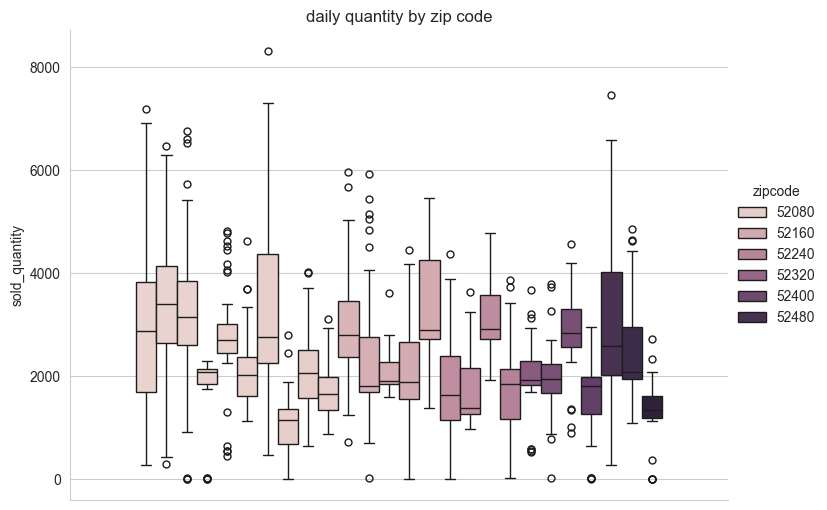

In [339]:
daily_quantity = df_train[['date', 'sold_quantity', 'zipcode', 'store_id']].groupby(['date', 'zipcode', 'store_id']).sum()
daily_quantity = daily_quantity.reset_index()
sns.catplot(y='sold_quantity', data = daily_quantity, hue = 'zipcode', kind = 'box', aspect = 1.5)
plt.title('daily quantity by zip code')

In [340]:
zipcode_mapping = daily_quantity.groupby(['zipcode'])['sold_quantity'].mean().to_dict()
X_train['zipcode'] = X_train['zipcode'].map(zipcode_mapping)
X_test['zipcode'] = X_test['zipcode'].map(zipcode_mapping)
X_train.head()

,date,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,2025-04-01,4.15,0,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
1,2025-04-01,1.70,0,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
2,2025-04-01,3.78,0,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
3,2025-04-01,3.80,0,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
4,2025-04-01,3.60,0,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0


### Encode store_id

In [341]:
daily_quantity = df_train[['date', 'sold_quantity', 'store_id']].groupby(['date', 'store_id']).sum()
daily_quantity = daily_quantity.reset_index()
store_mapping = daily_quantity.groupby(['store_id'])['sold_quantity'].mean().to_dict()
X_train['store_id'] = X_train['store_id'].map(store_mapping)
X_test['store_id'] = X_test['store_id'].map(store_mapping)
X_train.head()

,date,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,2025-04-01,4.15,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
1,2025-04-01,1.70,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
2,2025-04-01,3.78,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
3,2025-04-01,3.80,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0
4,2025-04-01,3.60,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,...,1,0,0,0,1,0,0,0,0,0


### Standardise the data

In [342]:
X_train_1 = X_train.drop('date', axis = 1)
X_test_1 = X_test.drop('date', axis = 1)
X_train_1.head()

,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,visibility,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,4.15,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,10.0,...,1,0,0,0,1,0,0,0,0,0
1,1.70,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,10.0,...,1,0,0,0,1,0,0,0,0,0
2,3.78,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,10.0,...,1,0,0,0,1,0,0,0,0,0
3,3.80,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,10.0,...,1,0,0,0,1,0,0,0,0,0
4,3.60,3728.519565,3040.958708,7.541667,16.5,78.625,1,0.0,64.458333,10.0,...,1,0,0,0,1,0,0,0,0,0


In [343]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_1 = pd.DataFrame(scaler.fit_transform(X_train_1), columns=X_train_1.columns)
X_test_1 = pd.DataFrame(scaler.transform(X_test_1), columns=X_test_1.columns)
X_train_1


,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,visibility,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
0,0.598423,1.139601,0.708513,-1.151002,0.961787,-0.953517,1.298559,-0.460468,-0.365679,0.361743,...,0.827587,-0.441047,-0.567569,-0.328301,1.988348,-0.49835,-0.434500,-0.35385,-0.429248,-0.287228
1,-0.609748,1.139601,0.708513,-1.151002,0.961787,-0.953517,1.298559,-0.460468,-0.365679,0.361743,...,0.827587,-0.441047,-0.567569,-0.328301,1.988348,-0.49835,-0.434500,-0.35385,-0.429248,-0.287228
2,0.415965,1.139601,0.708513,-1.151002,0.961787,-0.953517,1.298559,-0.460468,-0.365679,0.361743,...,0.827587,-0.441047,-0.567569,-0.328301,1.988348,-0.49835,-0.434500,-0.35385,-0.429248,-0.287228
3,0.425827,1.139601,0.708513,-1.151002,0.961787,-0.953517,1.298559,-0.460468,-0.365679,0.361743,...,0.827587,-0.441047,-0.567569,-0.328301,1.988348,-0.49835,-0.434500,-0.35385,-0.429248,-0.287228
4,0.327201,1.139601,0.708513,-1.151002,0.961787,-0.953517,1.298559,-0.460468,-0.365679,0.361743,...,0.827587,-0.441047,-0.567569,-0.328301,1.988348,-0.49835,-0.434500,-0.35385,-0.429248,-0.287228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182800,-1.240956,1.719103,1.008307,-0.674735,-1.385345,1.875802,-0.770085,4.655541,2.817941,-8.271198,...,-1.208332,2.267330,-0.567569,-0.328301,-0.502930,-0.49835,2.301497,-0.35385,-0.429248,-0.287228
182801,-1.028909,1.719103,1.008307,-0.674735,-1.385345,1.875802,-0.770085,4.655541,2.817941,-8.271198,...,-1.208332,2.267330,-0.567569,-0.328301,-0.502930,-0.49835,2.301497,-0.35385,-0.429248,-0.287228
182802,-0.856313,1.719103,1.008307,-0.674735,-1.385345,1.875802,-0.770085,4.655541,2.817941,-8.271198,...,-1.208332,2.267330,-0.567569,-0.328301,-0.502930,-0.49835,2.301497,-0.35385,-0.429248,-0.287228
182803,-0.979596,1.719103,1.008307,-0.674735,-1.385345,1.875802,-0.770085,4.655541,2.817941,-8.271198,...,-1.208332,2.267330,-0.567569,-0.328301,-0.502930,-0.49835,2.301497,-0.35385,-0.429248,-0.287228


In [344]:
X_train_1.describe()

,price,store_id,zipcode,temperature,wind_speed,wind_degree,wind_dir,precip,humidity,visibility,...,weather_description_clear,weather_description_cloudy,weather_description_rainy,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
count,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05,...,1.828050e+05,182805.000000,1.828050e+05,1.828050e+05,1.828050e+05,182805.000000,1.828050e+05,1.828050e+05,1.828050e+05,1.828050e+05
mean,1.094548e-16,-7.711588e-17,2.388105e-16,6.766296e-16,1.990087e-16,3.980174e-17,-1.890583e-16,-7.960349e-17,3.980174e-16,-3.383148e-16,...,-1.592070e-16,0.000000,1.194052e-16,-9.950436e-18,-1.492565e-17,0.000000,-1.194052e-16,4.975218e-18,1.194052e-16,1.094548e-16
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003,1.000003e+00,1.000003e+00,1.000003e+00,1.000003,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-4.604109e+00,-1.784434e+00,-2.223091e+00,-2.650359e+00,-1.672547e+00,-1.735978e+00,-7.700846e-01,-4.604680e-01,-2.555277e+00,-8.271198e+00,...,-1.208332e+00,-0.441047,-5.675694e-01,-3.283010e-01,-5.029301e-01,-0.498350,-4.344998e-01,-3.538503e-01,-4.292482e-01,-2.872279e-01
25%,-7.576872e-01,-7.729317e-01,-9.629728e-01,-7.629328e-01,-6.722924e-01,-8.954892e-01,-7.700846e-01,-4.604680e-01,-7.916888e-01,3.617431e-01,...,-1.208332e+00,-0.441047,-5.675694e-01,-3.283010e-01,-5.029301e-01,-0.498350,-4.344998e-01,-3.538503e-01,-4.292482e-01,-2.872279e-01
50%,-5.744116e-02,-1.245550e-01,3.219141e-01,-4.434552e-03,-3.157659e-01,-5.021210e-01,-7.700846e-01,-4.604680e-01,-7.251125e-02,3.617431e-01,...,8.275874e-01,-0.441047,-5.675694e-01,-3.283010e-01,-5.029301e-01,-0.498350,-4.344998e-01,-3.538503e-01,-4.292482e-01,-2.872279e-01
75%,4.406212e-01,7.065204e-01,8.711446e-01,8.246217e-01,6.745854e-01,8.758894e-01,1.298559e+00,-3.620832e-01,7.932503e-01,3.617431e-01,...,8.275874e-01,-0.441047,-5.675694e-01,-3.283010e-01,-5.029301e-01,-0.498350,-4.344998e-01,-3.538503e-01,-4.292482e-01,-2.872279e-01
max,2.222222e+01,2.321922e+00,1.280163e+00,1.794794e+00,2.526542e+00,2.364458e+00,1.298559e+00,7.410315e+00,2.817941e+00,3.617431e-01,...,8.275874e-01,2.267330,1.761899e+00,3.045985e+00,1.988348e+00,2.006623,2.301497e+00,2.826054e+00,2.329655e+00,3.481556e+00


#check seasonal effect
daily_quantity = df[['date', 'sold_quantity', 'store_id']].groupby(['date', 'store_id']).sum()
daily_quantity = daily_quantity.reset_index()
#print(len(daily_quantity_avg))
daily_quantity_avg = daily_quantity[['date', 'sold_quantity']].groupby('date').mean()
display(daily_quantity_avg.head(14))
plt.figure(figsize=(10, 15))
plt.plot(daily_quantity_avg.iloc[0:45])
plt.xticks(rotation = 60)

### Fit models

In [345]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train_1, y_train)
coef = list(lr.coef_)
coef.insert(0, lr.intercept_)
feats = list(X_train_1.columns)
feats.insert(0, 'intercept')
pd.DataFrame({'Estimate values': coef}, index = feats)

,Estimate values
intercept,17.838635
price,-0.213276
store_id,1.162352
zipcode,0.411930
temperature,-1.442786
wind_speed,0.097421
wind_degree,-1.073418
wind_dir,0.030102
precip,-0.658994
humidity,1.494105


0.703142723503965


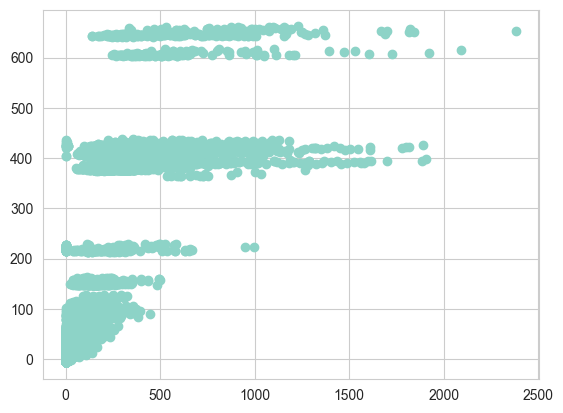

In [346]:
print(lr.score(X_train_1, y_train))
y_train_pred = lr.predict(X_train_1)
plt.scatter(y_train, y_train_pred)

0.6926875764688911


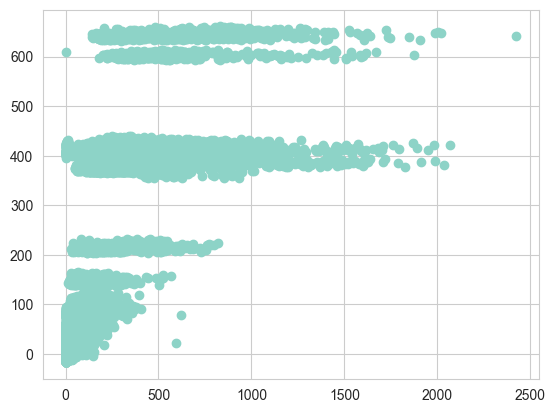

In [347]:
y_pred = lr.predict(X_test_1)
print(lr.score(X_test_1, y_test))
plt.scatter(y_test, y_pred)

random forest

0.703142723503965


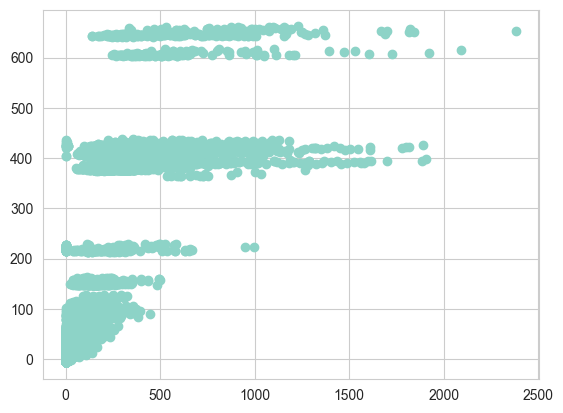

In [348]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators = 50, max_depth = 5, random_state = 10)
rf.fit(X_train_1, y_train)
print(lr.score(X_train_1, y_train))
y_train_pred = lr.predict(X_train_1)
plt.scatter(y_train, y_train_pred)